In [2]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Cargar el dataset
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
#Leer el dataset
data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

data_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
#Seleccionar columnas
columns = ["sepal length (cm)", "petal length (cm)", "target"]
#columns = ["sepal width (cm)", "petal width (cm)", "target"]
data_df = data_df[columns]
data_df.tail(5)

,sepal length (cm),petal length (cm),target
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2
149,5.9,5.1,2


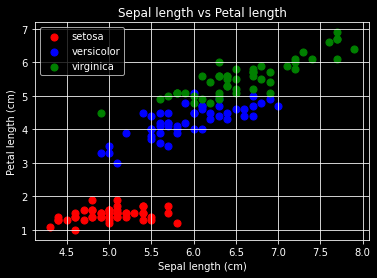

In [6]:
#Visualizar datos
plt.figure()
#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]
#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]
#Datos de iris virginica
virginica_data = data_df[data_df["target"] == 2]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="red", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)
plt.scatter(virginica_data["sepal length (cm)"], virginica_data["petal length (cm)"], label="virginica", color="green", s=50)

#plt.scatter(setosa_data["sepal width (cm)"], setosa_data["petal width (cm)"], label="setosa", color="red", s=50)
#plt.scatter(versicolor_data["sepal width (cm)"], versicolor_data["petal width (cm)"], label="versicolor", color="blue", s=50)
#plt.scatter(virginica_data["sepal width (cm)"], virginica_data["petal width (cm)"], label="virginica", color="green", s=50)

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')

#plt.title("Sepal width vs Petal width")
#plt.xlabel('Sepal width (cm)')
#plt.ylabel('Petal width (cm)')

plt.grid()
plt.legend()
plt.show()


In [7]:
X = data_df[["sepal length (cm)", "petal length (cm)"]].values
#print(X)

y = data_df["target"].values
print(y)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [8]:
#Dividir datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
mlp = MLPClassifier(hidden_layer_sizes=(100,150,), max_iter=300, activation='relu', random_state=42)
mlp.fit(X_train, y_train)

c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(100, 150), max_iter=300, random_state=42)

In [10]:
#Predecir los datos del conjunto de prueba
y_pred = mlp.predict(X_test)
print(y_pred)
print(y_test)


[1 0 2 1 1 0 1 1 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [11]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Exactitud: {accuracy:.2f}%")

Exactitud: 96.67%


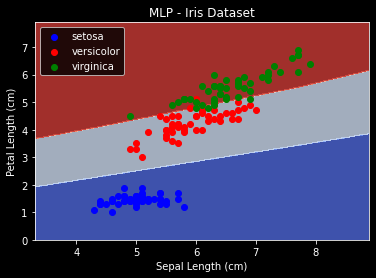

In [12]:
# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

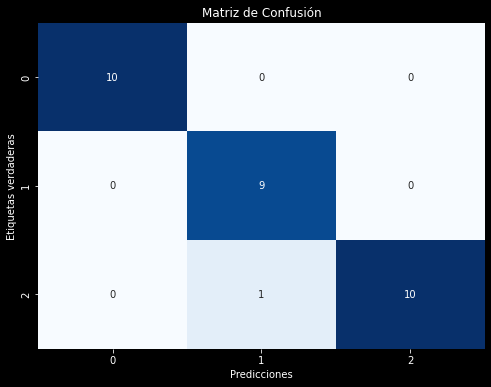

In [13]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()

In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

